<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFFF; max-width: 90%; overflow-x: auto;">

<img src="../../resources/swdb_logo.jpg">

<h1 align="center">Mini 4: Does arousal drive firing rate up or down?</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

***Authors:** Nick Steinmetz, Carrie Stine*

---

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto;">

## The Setup:

Across many sessions we recorded a neuron's firing rate and, on each trial, the animal's pupil size (a proxy for arousal).

</div>

In [1]:
# Setup (imports and plotting defaults)
import os
from pathlib import Path

if '__vsc_ipynb_file__' in dir():
    os.chdir(Path(__vsc_ipynb_file__).parent)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

In [2]:
# Load the dataset
d = np.load('data/data.npz')
pupil = d['pupil']                 # arousal proxy, per trial (0-1)
firing_rate = d['firing_rate']     # spikes/s, per trial
session_id = d['session_id']       # which session each trial came from
n_sessions = session_id.max() + 1
print(f'{len(pupil)} trials from {n_sessions} sessions')

420 trials from 7 sessions


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto;">

## The analysis: Pool all trials and fit firing rate vs. pupil

</div>

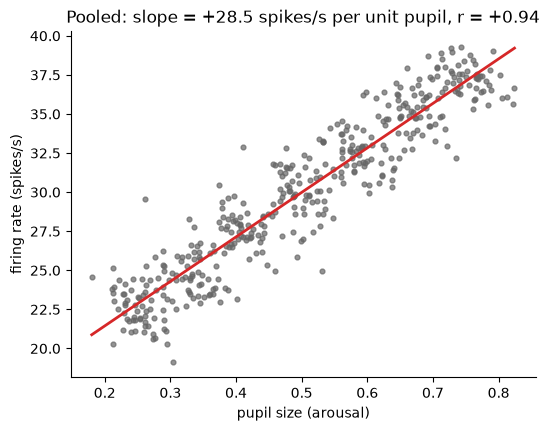

In [3]:
slope, intercept = np.polyfit(pupil, firing_rate, 1)   # linear fit to all trials
r = np.corrcoef(pupil, firing_rate)[0, 1]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pupil, firing_rate, s=12, color='0.4', alpha=0.7)
xs = np.array([pupil.min(), pupil.max()])
ax.plot(xs, intercept + slope * xs, color='tab:red', lw=2)
ax.set_xlabel('pupil size (arousal)'); ax.set_ylabel('firing rate (spikes/s)')
ax.set_title(f'Pooled: slope = {slope:+.1f} spikes/s per unit pupil, r = {r:+.2f}')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

The analysis shows a clear positive slope. A colleague concludes:

> *"Firing rate increases with arousal: across the dataset, pupil size and firing rate are positively correlated."*

**The claim is actually backwards.** Your job is to work out why.

</div>


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8; max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Evaluate the pooled correlation

Can you figure out why the conclusion is not supported? 

**Please spend at least the first 15 minutes working as a group without opening the hints or solutions.** Talk through what you think the code should do, sketch out an approach, and try writing it yourself, even if it's imperfect!

After 15 minutes if your group still feels genuinely stuck, you're welcome to reveal the hints below, or check the solutions notebook if needed.

---

<details>
<summary><b>Conceptual Hint 1</b></summary>

 The pooled fit throws every trial into one cloud. **_Is there a grouping variable in the data that is related to both pupil and firing rate?_** 

 <details>
 <summary><b>Coding Hint 1</b></summary>

 *Try coloring the same scatter plot by session. What does it look like if you plot the within-session fit for each session?*

 </details>

</details>

---

<details>
<summary><b>Conceptual Hint 2</b></summary>

 **_What is the slope within each session?_** How does that compare to the pooled slope?

 <details>
 <summary><b>Coding Hint 2</b></summary>

 *Calculate the within-session slope for each session (spikes/s per unit pipil) and plot the value for each session.*

 </details>

</details>

---

<details>
<summary><b>Conceptual Hint 3</b></summary>

 **_How could you estimate the within-session relationship to account for it before pooling?_** 

 <details>
 <summary><b>Coding Hint 3</b></summary>

 *Try removing each session's mean from both variables before pooling. Equivalently, fit a model with a per-session intercept (mixed/within-subject model).*
 
 </details>

</details>

---



</div>


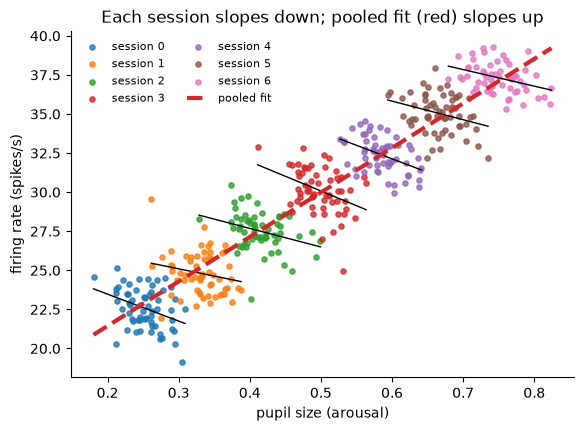

In [4]:
# Evidence 1: Color the same scatter by session
slope, intercept = np.polyfit(pupil, firing_rate, 1)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for s in range(n_sessions):
    m = session_id == s
    ax.scatter(pupil[m], firing_rate[m], s=14, alpha=0.8, label=f'session {s}')
    sl, ic = np.polyfit(pupil[m], firing_rate[m], 1)      # within-session fit
    xs = np.array([pupil[m].min(), pupil[m].max()])
    ax.plot(xs, ic + sl * xs, color='k', lw=1)
xs = np.array([pupil.min(), pupil.max()])
ax.plot(xs, intercept + slope * xs, color='tab:red', lw=3, ls='--', label='pooled fit')
ax.set_xlabel('pupil size (arousal)'); ax.set_ylabel('firing rate (spikes/s)')
ax.set_title('Each session slopes down; pooled fit (red) slopes up')
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.show()

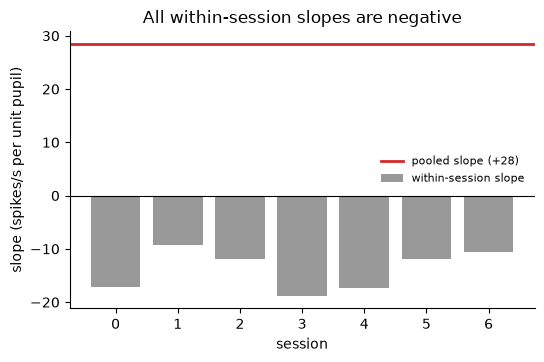

mean within-session slope: -13.9   pooled slope: +28.5


In [5]:
# Evidence 2: Compare within-session slopes vs pooled slope
within = np.array([np.polyfit(pupil[session_id == s], firing_rate[session_id == s], 1)[0]
                   for s in range(n_sessions)])

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(range(n_sessions), within, color='0.6', label='within-session slope')
ax.axhline(slope, color='tab:red', lw=2, label=f'pooled slope ({slope:+.0f})')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('session'); ax.set_ylabel('slope (spikes/s per unit pupil)')
ax.set_title('All within-session slopes are negative')
ax.legend(frameon=False, fontsize=8)
plt.show()
print(f'mean within-session slope: {within.mean():+.1f}   pooled slope: {slope:+.1f}')

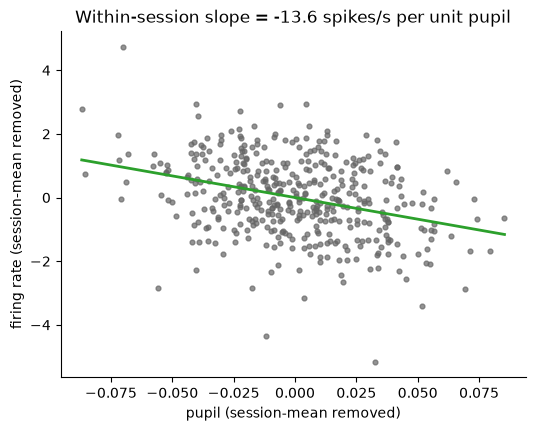

In [6]:
# Evidence 3: Analyze the within-session relationship
# Subtract each session's mean from both variables before pooling.
pupil_c = pupil.copy()
firing_c = firing_rate.copy()

for s in range(n_sessions):                    # subtract each session's means
    m = session_id == s
    pupil_c[m] -= pupil[m].mean()
    firing_c[m] -= firing_rate[m].mean()
slope_within, ic_within = np.polyfit(pupil_c, firing_c, 1)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pupil_c, firing_c, s=12, color='0.4', alpha=0.7)
xs = np.array([pupil_c.min(), pupil_c.max()])
ax.plot(xs, ic_within + slope_within * xs, color='tab:green', lw=2)
ax.set_xlabel('pupil (session-mean removed)'); ax.set_ylabel('firing rate (session-mean removed)')
ax.set_title(f'Within-session slope = {slope_within:+.1f} spikes/s per unit pupil')
plt.show()

<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

## Key takeaways

A relationship pooled across groups *can reverse the relationship within each group* (Simpson's paradox). It happens whenever the grouping variable (session, animal, subject) is related to both variables. 

- **Decide which question you are asking.** 'Do high-arousal sessions fire more?' (between-session) and 'Does arousal drive firing?' (within-session) are different questions. In this example, these questions have opposite answers.
- **Respect the grouping structure.** Analyze within group rather than pooling trials as if they were independent and exchangeable. 

</div>
